# IMT 573 - Final Examination


Points: 100

Name: Anika Mohan

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Anika Mohan

11.29.25



For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [96]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [97]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [98]:
affairs.info()
affairs.isnull().sum()
affairs.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   children         6366 non-null   float64
 4   religious        6366 non-null   float64
 5   educ             6366 non-null   float64
 6   occupation       6366 non-null   float64
 7   occupation_husb  6366 non-null   float64
 8   affairs          6366 non-null   float64
dtypes: float64(9)
memory usage: 447.7 KB


(6366, 9)

In [99]:
print(affairs['children'].mean())
print(affairs['age'].mean())

1.3968740182218033
29.082862079798932


(part a) --> Based on initial analysis there appears to be no missing data in any of the columns. There is 6366 rows and 9 columns. The average count of children is ~1.3 so between 1-2 kids do the participants who are performing extramarital sexual intercourse have. The average age of the participants is ~ 29 years. Some initial ethical or privacy concerns I have with the dataset is how this information was recorded given it's involving participants who stepped outside of their marriage which can be sensitive details not best for being publicized. Another initial concern I have of the dataset is why a seperata variable is husband_occupation- does that mean all the participants surveyed were women/wive? I would be interested to have more information on the type of participants included or the choice of what variables were collected

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [100]:
# create new variable that filters out values in 'affairs' column that are 0.0
# create a new variable (affairs_binary) that contains either False for they did not have an affair or True for they did have an affair
# go through each row and add a new variable called affairs_binary and for each row if affairs value is > 0, the affairs_binary column contains a 1 and if its equal than 0, affairs binary contains a 0
#no_affairs = affairs[affairs['affairs'] == 0.0]

#print(no_affairs)

affairs['affairs_binary'] = (affairs['affairs']>0)
#print(affairs.head())

no_affairs = affairs[affairs['affairs'] == 0.0]
print(no_affairs)


      rate_marriage   age  yrs_married  children  religious  educ  occupation  \
2053            4.0  32.0          9.0       2.0        3.0  14.0         2.0   
2054            4.0  27.0          6.0       0.0        2.0  14.0         3.0   
2055            4.0  22.0          2.5       0.0        2.0  14.0         3.0   
2056            5.0  42.0         23.0       4.0        3.0  16.0         3.0   
2057            5.0  27.0          2.5       1.0        3.0  20.0         2.0   
...             ...   ...          ...       ...        ...   ...         ...   
6361            5.0  32.0         13.0       2.0        3.0  17.0         4.0   
6362            4.0  32.0         13.0       1.0        1.0  16.0         5.0   
6363            5.0  22.0          2.5       0.0        2.0  14.0         3.0   
6364            5.0  32.0          6.0       1.0        3.0  14.0         3.0   
6365            4.0  22.0          2.5       0.0        2.0  16.0         2.0   

      occupation_husb  affa

(part b) ---> For this question I created the binary variable affairs_binary to represent the participants that participated in extramarital sexual intercourse and those who did not. The advantage to this is we can use the new variable to filter out the participants who did not participate in affairs, analyze their traits and infer correspondents for potentially why affairs might occur by comparing to the traits corresponding to those who did have affairs. For instance, we can compare average ages/range of ages for those who do/do not have affairs and see if there's a pattern for each situation. The potential downside to this method is it doesn't fully account for why people perform affairs vs people who don't as there could be external factors influencing this decision that's not fully represented by the data. 

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [101]:
# Use a Logistic regression to analyze the relationship between having an affair and two characteristics- religious & rate_married

features_col = ['religious', 'rate_marriage', 'age', 'yrs_married', 'children', 'educ', 'occupation_husb', 'occupation']


X = affairs[features_col]
X = sm.add_constant(X)  
y = affairs['affairs_binary']
log_reg = sm.Logit(y, X)
result = log_reg.fit()

print(result.summary())



Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         affairs_binary   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.1327
Time:                        19:19:16   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.7257      0.299     12.470      0.000       3.140       4.311
religious     

(part c) --> Using the logistic regression model results, we can see which variables (personal characteristics) are significant in predicting the affairs_binary variable by seeing which variable has a significant p-value (< 0.05) and which do not (> 0.05). Based on the results, Reglious, yrs_married, rate of marriage, age, occupation, and educ all are significant covariates in predicting affair outcome as their p-value show significant effects while children and the husband's occupation do not seem to be significant predictive variables. From the negative coefficient, it appears participants with higher religious lever, strong marital status, higher the age, higher education level are less likely to have an affair.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [102]:
# determine which models to remove/which to keep in the best fit model
# use stepwise selection (backwards elimination approach) to determine "best" fit model
# target variable --> affairs_binary
# predictors --> 'religious', 'rate_marriage', 'age', 'yrs_married', 'children', 'educ', 'occupation_husb', 'occupation'
X = ['religious', 'rate_marriage', 'age', 'yrs_married', 'children', 'educ', 'occupation_husb', 'occupation']
y = affairs['affairs_binary']
def get_stats():
    x = sm.add_constant(affairs[X])
    model = sm.Logit(y, x).fit()
    print(model.summary())
# drop the variables with p-value greater than 0.5 --> children, occupation_husb
X.remove("children")
X.remove("occupation_husb")
get_stats()

Optimization terminated successfully.
         Current function value: 0.545339
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         affairs_binary   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.1326
Time:                        19:19:16   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.7371      0.296     12.622      0.000       3.157       4.317
religious        -0.

(part d) ---> here to determine the "best fit" model i used a backwards stepwise selection based on logistic regression p-values. Where I first started out with all 8 predictors then removed the variables, children & occupation_husb as their p-values were not statistically significant. After removing those variables, all the predictors were at the significant at the 5% which is where the stepwise selection procedure stopped. Thus the best fit model is different than the full model, as it is short of the two removed variables.

(e) Interpret the model parameters using the model from part (d).

1. Religiousness has a coef of -0.370 indicating a one year increase in religiousness score is associated with a lower likliehood of an affair
2. Rate of Marriage had a coef of -0.7153 indicating a one year increase in marital status is associated with a lower log-odds of an affair
3. age had a coef of -0.0602 indicating a one year increase in age of the participant is associated with a lower log-odds of an affair
4. yrs_married had a coef of 0.109 indicating a one-year increase in time being married is associated with a higher-odds of having an affair
5. educ had a coef of -0.03 indicating a one year increase in level of education obtained is associated with a lower log-odds of an affair
6. occupation had coef of 0.1628 indicating a one unit increase in the occupation level is associated with a higher log-odds of an affair occuring.

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

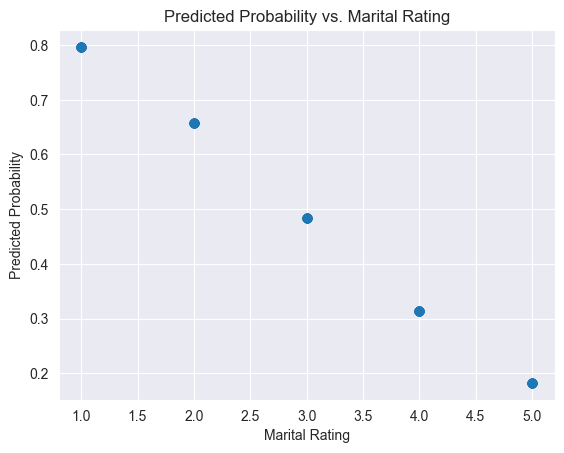

In [103]:
np.random.seed(42)
n = 200
# set the variables (except rate_marriage) to their mean
predictors = ['religious', 'rate_marriage', 'age', 'yrs_married', 'children', 'educ', 'occupation_husb', 'occupation']
pred_mean = affairs[predictors].mean()

test_dataset = pd.DataFrame({
    'rate_marriage': np.random.randint(1, 6, size=n),
    'religious': pred_mean['religious'],
    'age': pred_mean['age'],
    'yrs_married': pred_mean['yrs_married'],
    'educ': pred_mean['educ'],
    'occupation': pred_mean['occupation'],
    'children': pred_mean['children'],
    'occupation_husb': pred_mean['occupation_husb']
})

X_test = sm.add_constant(test_dataset, has_constant='add')
X_test = X_test[['const'] + predictors]

test_dataset['pred_prob'] = result.predict(X_test)
# plot the predicted probability of an affair as it changes as rate_marriage changes
plt.scatter(test_dataset['rate_marriage'], test_dataset['pred_prob'])
plt.xlabel("Marital Rating")
plt.ylabel("Predicted Probability")
plt.title("Predicted Probability vs. Marital Rating")
plt.show()

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

----> From the visualization and results of the artificial test dataset, we can see the predicted probability of having an affair is showing a downward trend as marital rating increases. What this shows is that several personal characteristics were significantly associated with having an affair and there were also some variables that weren't meaningful. Because all other variables were held constant at their mean, we can assume that marital status satisfaction alone has a strong predictive effect against the likliehood of an affair happening. After completing this analysis, I still have ethical concerns over the safetiness of this study and how personal characteristics were even recorded given this is a emotionally charged situation. Another concern I have is while the predictive model is being deemed successful, prediciting about infedility based off other characteristics can run the risk of enforcing stereotypes. 

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [104]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

(part a) ---> My question I'll be exploring through my analysis is: Does the amounnt of experienced (measured by years) a Player has influence their Salary?
This question will involve a simple linear regression, establishing the predictor (X): years (which is the number of years the player has played in the major leagues) and the Outcome (Y): Salary (which is the annual salary received)

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [105]:
print(Hitters.info())

print(Hitters.describe(include='all'))

print(Hitters.shape)

print(Hitters.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

(part b) ---> The Hitters dataset contains 322 observations and 20 variables describing performance statistics and league information for the baseball players. Most of the variables are numerical while the three variables, League, Division, and NewLeague are categorical. From the summary stats, the dataset shows that years of experience ranges from 0-24 years and the salaries range from ~ 67.5K ti 2.46M. Some issues that'll need to be resolved before conducting the analysis is that the Salary column contains 59 missing values and it utilizing the categorical columns, they would need to be converted into numerical form if used in modeling. 

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

0      False
1      False
2      False
3      False
4      False
       ...  
317    False
318    False
319    False
320    False
321    False
Name: Years, Length: 322, dtype: bool
0       True
1      False
2      False
3      False
4      False
       ...  
317    False
318    False
319    False
320    False
321    False
Name: Salary, Length: 322, dtype: bool


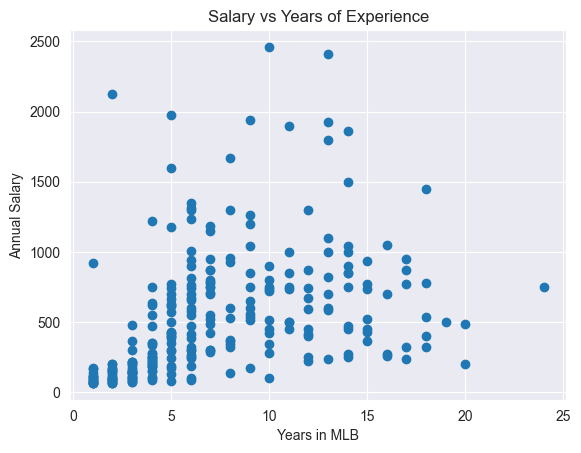

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     49.91
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           1.46e-11
Time:                        19:19:16   Log-Likelihood:                -1957.1
No. Observations:                 263   AIC:                             3918.
Df Residuals:                     261   BIC:                             3925.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        260.2341     46.636      5.580      0.0

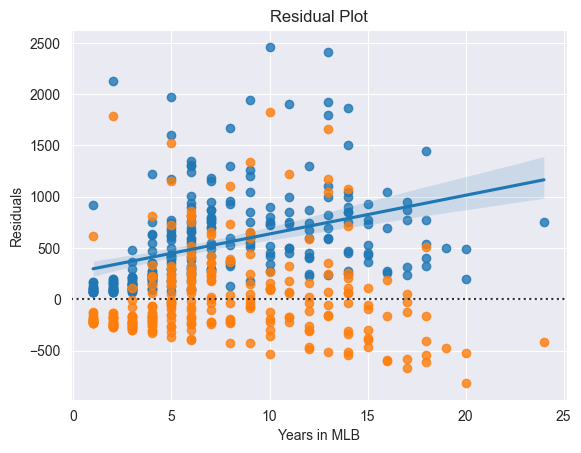

In [106]:
# For this question we'll be focusing on the 'Years' and 'Salary' columns
# first check for missing values
missing_years = Hitters['Years'].isnull()
print(missing_years)

missing_salary = Hitters['Salary'].isnull()
print(missing_salary)

#drop rows in 'Salary' column with missing values
Hitters_copy = Hitters.dropna(subset=['Salary'])

# set predictor variable (x): Years (independent)
# Set the dependent variable (y): Salary
X = Hitters_copy[['Years']]
y = Hitters_copy['Salary']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# First visualization- Scatterplot
plt.scatter(X, y)
plt.xlabel("Years in MLB")
plt.ylabel("Annual Salary")
plt.title("Salary vs Years of Experience")
plt.show()

# Run a simple linear regression
X_ols = sm.add_constant(Hitters_copy['Years'])
y_ols = Hitters_copy['Salary']
model = sm.OLS(y_ols, X_ols).fit()
print(model.summary())

# Second Visualization- Reglplot()
sns.regplot(data=Hitters_copy, x="Years", y="Salary")

# Third Visualization- Residual Plot
sns.residplot(x='Years', y='Salary', data=Hitters_copy)
plt.xlabel("Years in MLB")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

(part d) --> From the OLS result: The coefficient for Years is 37.70 which means that with each additional year in the MLB, is an associated increase of about $37,700 in salary (thousands). The P-value was equal to 0.000 which means the relationship was statistically significant (less thab 0.05) and the R-squarerd is equal to 0.161 which means that only 16.1% of salary variation can be explained by years of experienced. What this all tells us is that the Years of experience does have a significant positive effect but also that it explains very little of why salaries vary. This prompts me to believe that Salaries depend on other factors, such as performance, contracting, team, position- and not just years. These interpretations can also be supported by the visuals. The first visualization, the Scatterplot of Salary vs Years of Experience shows a week but still significant upward pattern- showing that players with more years in the MLB tend to have higher salaries. However, the wide spacing of the points are also an indication that years isnt the only determinant of salary. Likewise, the secon visualization (Residual Plot) shows a large spread of residuals at almost every level of experience, with some visible patterns and many of the residuals appearing far above and below zero. What this indicates is that the linear model does not fit the data very well and that assumptions of the linear regressions aren't met- which supports the finding that Years alone is not a strong predictor of Salary.

I was for the most part able to answer the analysis question. Looking back however, while I do think the question was well-defined in terms of what variables we're analyzing to see if there's a potential relationship and the linear rgeression model was defined clearly enough to showcase that, I think there is potential to expand on this question (potentially a multiple linear regeression or another form of modeling) to consider other factors, alongside years, as a determinant of Salary since we now know the relationship isn't as strong as was predicted before. The data however, is solid enough to expand further but a question I do have is what the units are for Salary given that was a doubt I had while conducting the analysis. 

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [107]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [108]:
print(df.dtypes)


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

0.0679982268479048


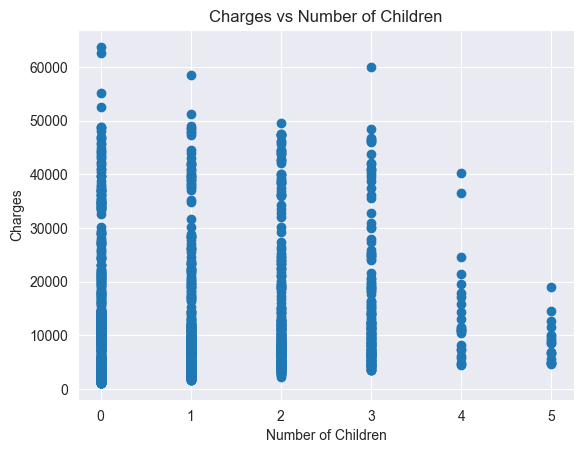

In [109]:
# To examine the bivariate relationships, can use a scatterplot to visualize each pair of data values and calculate the correlation
# Charges is the Outcome we're exploring
# the other variables are the chsracteristics
# Numeric to Numeric use: Scatterplots and correlations
# Categorical to Numeric useL Boxplot, Bar chart, Group summaries


# Charge vs children
plt.scatter(df['children'], df['charges'])
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.title('Charges vs Number of Children')
corr_chd = df['children'].corr(df['charges'])
print(corr_chd)



0.19834096883362884


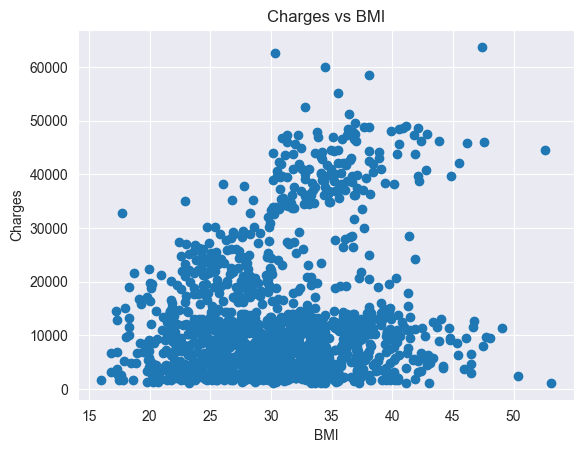

In [110]:
# Charge vs bmi
plt.scatter(df['bmi'], df['charges'])
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('Charges vs BMI')
corr_bmi = df['bmi'].corr(df['charges'])
print(corr_bmi)

0.29900819333064754


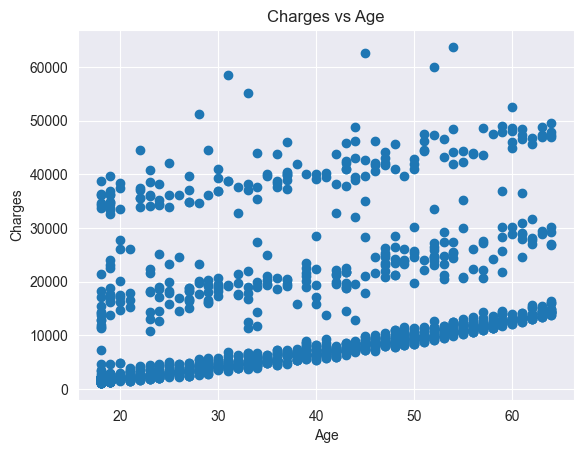

In [111]:
# Charges vs Age: 
plt.scatter(df['age'], df['charges'])
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Charges vs Age')
corr_age = df['age'].corr(df['charges'])
print(corr_age)

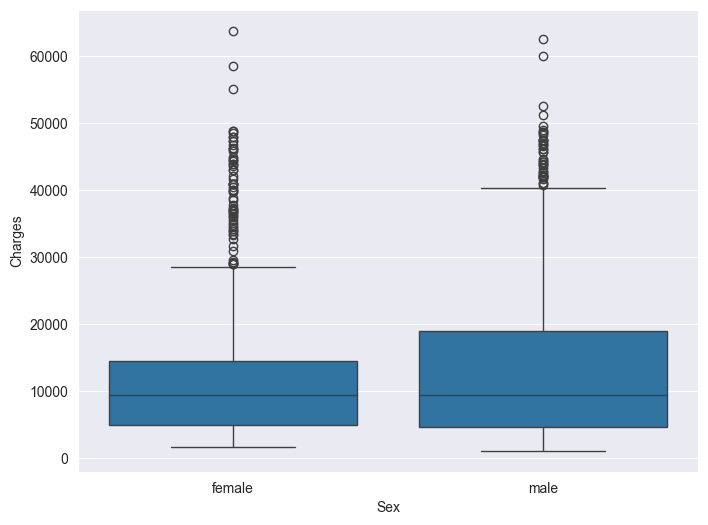

In [112]:
# Charges vs Sex: Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='sex', y='charges', data=df)
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.show()


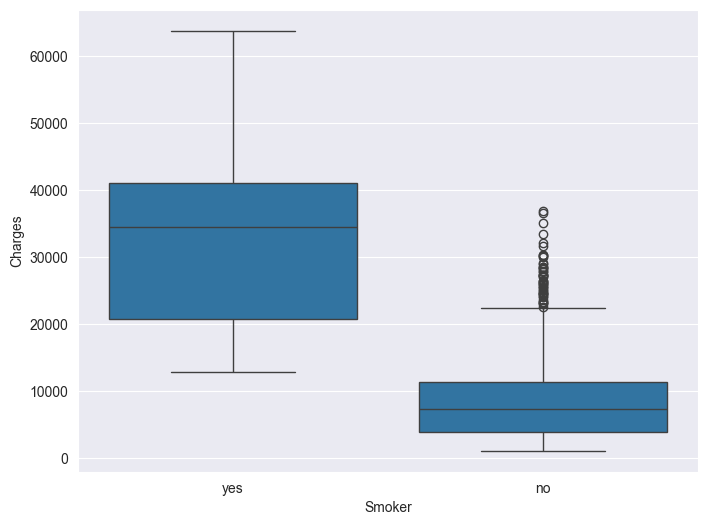

In [113]:
# Charges vs smoker: Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

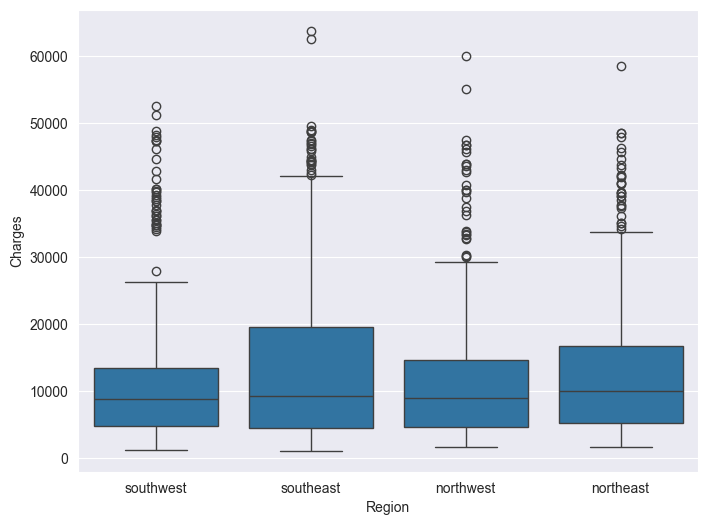

In [114]:
# Charges vs region: Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='region', y='charges', data=df)
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

In [115]:
# Charges vs Sex: Grouping by mean
print(df.groupby('sex')['charges'].mean())

# Charges vs Smoker
print(df.groupby('smoker')['charges'].mean())

# Charges vs region
print(df.groupby('region')['charges'].mean())


sex
female    12569.578844
male      13956.751178
Name: charges, dtype: float64
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64
region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


(part a)

1. Charges vs Age:
The scatterplot shows an upward trend with charges increasing as age increases as well- indicating that older individuals generally have higher charges. The correlation of +0.299 is considered a weak to moderate positive correlation showung that its not a strong relationship

2. Charges vs BMI
The scatterplot of charges vs BMI shows a weak positive relationship as with BMI increasing, the charges tend to increase slighly which is consistnt with the low correlation value ~ 0.20.

3. Charges vs Number of Children
The relationship between num of children and charges is very week as the correlation is close to zero ~0.07 and the scatterplot shows no clear upward or downward trend. This suggests that family size plays a minimal role in determining medical charges/expenses in this dataset.

4. Charges vs Sex
the charges appear very similar for males and females. The grouped mean charges for men and female are close in value, indicating that sex has no meaningful relationship with medical charges in the dataset

5. Charges vs Smoker
There is a strong positive relationship betwee smoking status and medical charges as visible in the boxplot where the smoker group shows a much higher median and wider range of outliers as well as the mean charge for smokers is around 4x larger than that of non-smokers- making smoking status the strongest predictor of all the bivariate relationships analyzed

6. Charges vs Region
The charges do not differ too much across regions and the boxplot shows similar distributions with heavy overlap which suggests that geographic region has little influence in determing medical charges in this datase


(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [116]:
characteristics = [
    'age',
    'bmi',
    'children',
    'sex',
    'smoker',
    'region'
]

X = pd.get_dummies(df[characteristics], drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)


y = df['charges']

multi_reg = sm.OLS(y, X).fit()

print(multi_reg.summary())

# Calculate the variance of medical charges as explained by bmi via use of pearson correlation
# variance will be explained by the squared pearson correalation

pearson_r = df['bmi'].corr(df['charges'])
bmi_var = (pearson_r)**2
print()
print(bmi_var)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:19:17   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

(part b) ---> From fitting a multiple linear regression model, the R-squared value comes out to be 0.751 which means the model explains 75.1% of the variance in medical charges. Given the BMI's p-value is 0.000, which is less than the 5% threshold, this makes the bmi predictor very statistically significant. Using the pearson correlation between BMI and medical charges, which gives r=0.198- squaring thsi value gives r^2 ~ 0.04- meaning that BMI alone explains 4% of the variance in medical costs.

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

0       -8408.789028
1       -1723.050534
2       -2257.526491
3       18229.640447
4       -1725.638186
            ...     
1333    -1750.775386
1334    -1305.950009
1335    -2519.298986
1336      761.360061
1337    -7944.262968
Length: 1338, dtype: float64


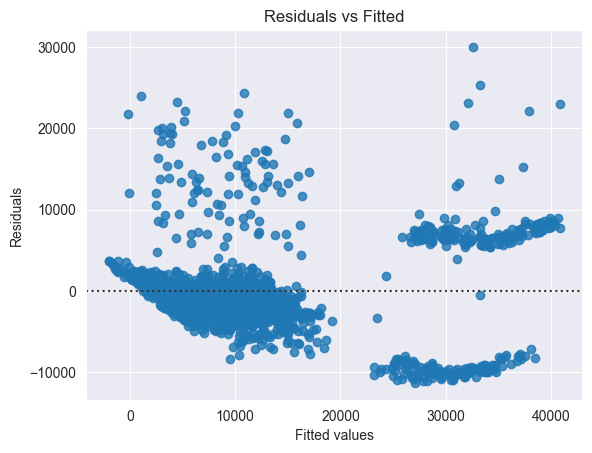

In [117]:
pred_values = multi_reg.predict(X)
residuals = y - pred_values
print(residuals)

sns.residplot(data=df, x=pred_values, y=residuals)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

(part c) ---> Able to evaluate the statistical assumptions in the regression analysis from earlier uising a residuals vs fitted values plot. There are a few concerns the plot reveals. The first being that the residuals show a clear curved pattern rather than just a random scatter which suggests the linear model isn't fully capturing all the observed relationships between predictors and medical charges. Another concern about the model is the wide spread of residuals and the inconsistency of the spread as the fitted values increase indicastes a non-consistent variance. Lastly, there are some extra residual outliers, such as ones exceeding 20,000 and reaching 30,000 which could likely be representing the exceedingly high/unprecented medical expenditures but because of their extremity, these outliers could have a significant effect on the model.

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [118]:
# Backwards stepwise model selection procedure- top to bottom; remove independent variables with the highest p-value
# # drop the variables with p-value greater than 0.5 --> children, occupation_husb
predictors_og = list(X.columns)
predictors_og_orig = predictors_og.copy()
predictors_og.remove('const')
sig_level = 0.05
for value in range(len(predictors_og)):
    X_curr = X[['const'] + predictors_og]
    model = sm.OLS(y, X_curr).fit()
    pvals = model.pvalues.drop('const')
    bad_var = pvals.idxmax()
    max_p = pvals.max()
    if max_p > sig_level:
        print(f'Removing {bad_var} due to p-value of {max_p:.3f}')
        predictors_og.remove(bad_var)
    else:
        break
X_new = X[['const'] + predictors_og]
best_model = sm.OLS(y, X_new).fit()
print(best_model.summary())

Removing sex_male due to p-value of 0.693
Removing region_northwest due to p-value of 0.460
Removing region_southwest due to p-value of 0.059
Removing region_southeast due to p-value of 0.136
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     998.1
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:19:17   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1333   BIC:                         2.714e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 c

In [119]:
predictors_og = predictors_og_orig.copy()
for value in range(len(predictors_og)):
    X_curr = X[['const'] + predictors_og]
    print(value, X_curr.columns)
    model = sm.OLS(y, X_curr).fit()
    pvals = model.pvalues.drop('const')
    bad_var = pvals.idxmax()
    max_p = pvals.max()
    if max_p > sig_level:
        predictors_og.remove(bad_var)
    else:
        break

0 Index(['const', 'const', 'age', 'bmi', 'children', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')
1 Index(['const', 'const', 'age', 'bmi', 'children', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')
2 Index(['const', 'const', 'age', 'bmi', 'children', 'smoker_yes',
       'region_southeast', 'region_southwest'],
      dtype='object')
3 Index(['const', 'const', 'age', 'bmi', 'children', 'smoker_yes',
       'region_southeast'],
      dtype='object')
4 Index(['const', 'const', 'age', 'bmi', 'children', 'smoker_yes'], dtype='object')


(part d) --> After performing a backwards selection elimination, the best fit model only includes the predictors that have statistically significant p-values: age, bmi, children, smoker_yes (converted to a dummy variable to perform regression) which are the strongest predictors in the dataset while everything else has been dropped. 

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [120]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

url = location + dataframe
columns = [
    "Sample_code_number",
    "Clump_thickness",
    "Uniformity_of_cell_size",
    "Uniformity_of_cell_shape",
    "Marginal_adhesion",
    "Single_epithelial_cell_size",
    "Bare_nuclei",
    "Bland_chromatin",
    "Normal_nucleoli",
    "Mitoses",
    "Class"
]
df = pd.read_csv(url, names=columns)
df = df.replace("?", np.nan)
print(df.head())

   Sample_code_number  Clump_thickness  Uniformity_of_cell_size  \
0             1000025                5                        1   
1             1002945                5                        4   
2             1015425                3                        1   
3             1016277                6                        8   
4             1017023                4                        1   

   Uniformity_of_cell_shape  Marginal_adhesion  Single_epithelial_cell_size  \
0                         1                  1                            2   
1                         4                  5                            7   
2                         1                  1                            2   
3                         8                  1                            3   
4                         1                  3                            2   

  Bare_nuclei  Bland_chromatin  Normal_nucleoli  Mitoses  Class  
0           1                3                1        1

(part a) --> the dataset contains 699 observations and 11 variables from the Wisconsin Breast Cancer dataset. Where each observation corresponds to a sample taken of a breast mass injection. Each observation is measured under one identifier (the sample code number for identification) and the nine predictors describing characteristics of cell nucle. The purpose of this analysis is to use the predictors to determine whether observations are benign or maligant. All missing values have been converted to nAn.

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [121]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample_code_number           699 non-null    int64 
 1   Clump_thickness              699 non-null    int64 
 2   Uniformity_of_cell_size      699 non-null    int64 
 3   Uniformity_of_cell_shape     699 non-null    int64 
 4   Marginal_adhesion            699 non-null    int64 
 5   Single_epithelial_cell_size  699 non-null    int64 
 6   Bare_nuclei                  683 non-null    object
 7   Bland_chromatin              699 non-null    int64 
 8   Normal_nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB
None
       Sample_code_number  Clump_thickness  Uniformity_of_cell_size  \
count        6.990000e+02 

In [122]:
print(df.isna().sum())

Sample_code_number              0
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


(part b) --> The dataset contains 11 variables including identifer (sample_code_number), nine numeric predictors- describing characteristics of cell nuclei which will be used to indicate. However, there appears to be 16 missing values in the Bare_nuclei column so before conducting any modeling, these values will need to be either removed or taken careof. 

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

df_clean = df.dropna()   

X = df_clean.drop(columns=["Sample_code_number", "Class"])
y = df_clean["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

     Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
183                5                        8                         8   
472                6                        1                         1   
444                5                        1                         1   
85                 5                       10                         6   
516                1                        1                         1   
..               ...                      ...                       ...   
73                 9                        4                         5   
108                1                        1                         1   
279               10                        5                         7   
450                4                        1                         1   
104               10                       10                        10   

     Marginal_adhesion  Single_epithelial_cell_size Bare_nuclei  \
183                  8          

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [124]:
# choice of ML model- logistic regression
log_reg = LogisticRegression(max_iter=1000, solver="liblinear")
log_reg.fit(X_train, y_train)

y_pred_logreg = log_reg.predict(X_test)

# confusion matrix
cm_log = confusion_matrix(y_test, y_pred_logreg)
print("Logistic Regression: Confusion Matrix")
print(cm_log)


Logistic Regression: Confusion Matrix
[[125   2]
 [  8  70]]


/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


(part d) From the confusion matrix, the model correctly identified 125 benign samples as benign. The model incorrectly labeled 2 benign samples as malignant. The model incorrectly labeled 8 malignant samples as benign. Lastly, the model correctly identified 70 malignant samples. Given that the model correctly classified most benign cases (125/127) and most of the malignant cases (70/78), it's safe to say the model performed very well with only 10 errors. I would say however that in a cancer diagnosis, the most problematic error would be mislabeling malignant (cancerous) cells as benign (non-cancerous) as this is essentially a false negative and can delay neccesary treatment and allow the cancer to progress if cancerous cells are being passed off as safe/'okay'. In comparison with mislabeling benign cells as malignant, which is less severe, given this only results in further tests that would then reconfirm the mistake

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

(part a) -->

A real life application in which classification might be useful is for Medical Diagnosis and classifying patient data for specific diseases based on symptoms and test results. In this situation, the response (which is what you're trying to classify) would be whether or not a patient has i.e. COVID-19 (infectious disease) with Class 1 = Covid and Class 0 = Covid-Free. Covid/No Covid is a binary category which meets the requirement to be a classifcation response. Predictors be the patient's characteristics and could include: Age, Blood Pressure, Oxygen levels, fever (yes or no), recent exposure (y/n), cough status. The goal in this application would be prediction because the objective is to accurately diagnose new patients as either positive or neg. covid-19 to then further develop plans for treatment or infection control. 

Another real life application where classification might be useful would be predicting whether an applicant will be accepted to a college/university. In this situation the response would be the admission decision (categorical): Class 1 = Accepted, Class 0 = Rejected. Predictors would be variables or factors that are apart of influencing college decisions and are aspects included in the college application process, such as i.e. high school GPA, extracurriculars, standardized test scores (SAT or ACT), credits taken, volunteer hours, personal essay scores, or demographic information (i.e. affirmative action). The goal in this application would be prediction given it's predicting the likliehood of admission based off inputs. This could be useful for high schools or applicants to use the statistical models to estimate their chances or prep in advance their stats to better their odds. 

A third real life application where classification might be useful is for classifying what factors went into a company becoming successful or not. In this case, the response would be categorically measuring the success with Class 1 = Successful company and CLass 2 = Unsuccessful comapny. This case might be a bit subjective given successful would have to be carefully defined. But in a financial sense, if executives or financial analysts of a new company wanted to use classification to infer what makes some companies succeed while others dont, they could define successful as profitable and strong ROIs. Predictors would include business factors such as: market share, start up capital, marketing expenditure, initial company size, number of competitors. The goal of this application would be inference given its identifying which predictors significantly contribute to a company's success and understanding what makes companies succeed and others don't.

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

(part b) --> regression is predicting a numeric outcome

A real life application in which regression would be useful might be in predicting a sports game final score i.e. The Superbowl game and final scores of two football teams. In this case the response would be the number of points scored by each team. Predictors for this would be aspects of the game itself and football, such as: Team's average points per game during the season, quarterback performance stats, injuries, weather condition for that game (i.e. raining or not), home-field or not, # of rookies vs Seeasoned veternas, past super bowl wins. The goal in this application would be prediction as you're forcasting the final scoring with less focus on what's influencing the result.

Another real life application would be infering what factors after GPA. In this case it would be an inference application given the purpose is understanding how different variables interact and relate to a student's GPA. Predictors would include academic factors such as: How much the student studied, attendance record, how much sleep they got, course difficulty, and number of classess they're taking at the same time. It'd be useful for academic advisors or educators to understand how much each variable contributes or answer questions regarding correlation between study time or sleep quality and resulting grades.

Lastly, a real life application where regression would be useful is predicting future sales based off historical trends and market data. In this case the response would be sales revenue (either for a store or a specific product launch). Predictors would include: advertisting for the product/store, pricing, competitor pricing, economic conditions, consumer accessibility, customer demographic- factors that all play a part into resulting sales. The goal in this application would be prediction given it could help company execs in predicting future sales and help manage inventory or future budgeting. 


(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

(part c) ---> Some advantages to a more flexible model could be more preciseness and accuracy in making better predictions, especially when the true relationship is non-linear, which can help combat/reduce bias. Flexible models are also more effective at modeling more complex data, where as non-flexible models night overlook some covariate relationships. However, a disadvantge to a flexible approach is it requires a latge sample size (number of observations) and more defined parameters. Another con is the chance of overfitting as with such a high number of parameters it may cause the model to learn the training data too well in that it fails to generalize a theory or assumption that is applicable for new data and is too niche to the training data.

A situation where a flexible approach may be preferred to a less flexible approach is when the relationshop is non-linear or more complex. Also, when you have a larger sample size/dataset and are expecting more fluctuations in the trends that a flexible approach would be more competent in picking up. On the contrary, when the relationship is more simple and the focus is on interpreting and making an assumption, a non-flexible approach would be more suited as it reduces the risk of overfitting and is better at working with smaller datasets to justify. 



### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

(part a) ---> correct answer: part ii


 First start off solving this but manually writing out multi linear regression model: Y = 50 + 20(GPA) + 0.07(IQ) + 35(Gender) + 0.01(GPA * IQ) - 10(GPA * Gender). Then, since each of the options hold a fixed value of IQ and GPA, we can compare males vs females by using the model to calculate the salary for Males (setting Gender = 0) for Y_males and then calculating the salary for Females (Gender = 1) for Y_females. Y_Females - Y_males --> (50+20GPA + 0.07IQ + 35 + 0.01GPA * IQ - 10GPA) - (50+20GPA + 0.07IQ + 0 + 0.01GPA * IQ + 0) which results in --> 35 - 10(GPA). To determine the difference or when the difference (of who earns more) favors each gender is by setting the inequality: either Y_male > 0 or Y_female < 0 and solving for GPA. After doing that you get: females being favored when GPA < 3.5 and males when GPA > 3.5. Given this, the answer is part ii as males will earn more on average than females provided the gpa is high enough (higher than 3.5) 

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

coefficients:

B0 = 50
B1 = 20
B2 = 0.07
B3 = 35
B4 = 0.01
B5 = -10

lst_sqr = 50 + 20x_1 + 0.07x_2 + 35x_3 + 0.01x_1*x_2 - 10x_1*x_3

x_1 = GPA ; x_2 = IQ ; x_3 = Gender (female = 1)

To predict the salary of a female with IQ 110 and GPA 4.0 you just plug in the values: GPA = 4.0, IQ = 110, Gender = 1 (given its female)

Y_salary = 50 + 20(4.0) + 0.07(110) + 35(1) + 0.01(4 * 110) - 10(4 * 1)
Y = 50 + 80 + 7.7 + 35 + 4.4  - 40
Y_salary = 137.1

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

(part c) --> This is False, a small coefficient for the interaction terms doesn't indicate the interaction was unimportant/has no effect. Because even though the coefficient itself is a small number, it becomes significant when being multiplied by GPA*IQ, a very big number. If GPA is at 4.0 and IQ at 110, the coefficient 0.01 is being multipled by 4.0* 110 which is 0.01 * 400 = 4 --> which is a 4,000 difference in the outcome (salary). To gather evidence of an effect of specific terms/predictors, you would need to look at the p-values and t-statistics to measure the effect.

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  